# Big Data Analytics Platform using Apache Spark (PySpark)
### Case Study Solution — Retail Analytics & Recommendation System

**Steps covered:** Spark Init → RDD → Key-Value + Persistence → DataFrames → EDA + Spark SQL → ETL → Machine Learning

Run cells top to bottom. Cell 1 creates the dataset automatically, so nothing extra is needed.

## STEP 0: Generate Synthetic Dataset (customer transactions)

In [1]:
# Creates synthetic_transactions.csv (5000 records) using plain Python
import csv, random
from datetime import datetime, timedelta

products = {
    "Laptop": ("Electronics", 800), "Mobile": ("Electronics", 500), "Headphones": ("Electronics", 60),
    "TV": ("Electronics", 700), "Shirt": ("Clothing", 25), "Jeans": ("Clothing", 40),
    "Shoes": ("Clothing", 55), "Rice": ("Grocery", 10), "Oil": ("Grocery", 8),
    "Book": ("Stationery", 12), "Pen": ("Stationery", 2), "Sofa": ("Furniture", 400)
}

random.seed(42)
start = datetime(2024, 1, 1)

with open("synthetic_transactions.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["transaction_id", "customer_id", "product", "category", "quantity", "price", "purchase_date"])
    for i in range(1, 5001):
        p = random.choice(list(products))
        cat, base = products[p]
        qty = random.randint(1, 5)
        price = round(base * random.uniform(0.9, 1.1), 2)
        date = (start + timedelta(days=random.randint(0, 364))).strftime("%Y-%m-%d")
        w.writerow([i, "C" + str(random.randint(1, 200)), p, cat, qty, price, date])

print("Dataset created: synthetic_transactions.csv (5000 rows)")

Dataset created: synthetic_transactions.csv (5000 rows)


In [2]:
# Visualization libraries (install once if needed: pip install matplotlib pandas)
import matplotlib.pyplot as plt
import pandas as pd
plt.rcParams["figure.figsize"] = (8, 4)
print("Matplotlib ready for EDA charts")

Matplotlib ready for EDA charts


## Q1. Spark Initialization and Data Loading (2 Marks)
- **SparkSession** = entry point for DataFrames & SQL
- **SparkContext** = entry point for RDDs (available via `spark.sparkContext`)

In [3]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, count, avg, month

# Initialize Spark Session
spark = SparkSession.builder.appName("RetailAnalytics").getOrCreate()

# Spark Context (for RDD operations)
sc = spark.sparkContext
print("Spark Version:", spark.version)

# Load the customer transaction dataset
df = spark.read.csv("synthetic_transactions.csv", header=True, inferSchema=True)

# Display schema and sample records
df.printSchema()
df.show(5)
print("Total Records:", df.count())

Spark Version: 4.0.3
root
 |-- transaction_id: integer (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- price: double (nullable = true)
 |-- purchase_date: date (nullable = true)

+--------------+-----------+-------+-----------+--------+------+-------------+
|transaction_id|customer_id|product|   category|quantity| price|purchase_date|
+--------------+-----------+-------+-----------+--------+------+-------------+
|             1|        C63|    Pen| Stationery|       1|  1.81|   2024-05-20|
|             2|       C190|     TV|Electronics|       2|733.11|   2024-12-12|
|             3|         C8|    Oil|    Grocery|       1|  8.14|   2024-01-17|
|             4|         C7| Mobile|Electronics|       2|473.27|   2024-11-04|
|             5|       C140|    Oil|    Grocery|       2|  8.35|   2024-12-25|
+--------------+-----------+-------+-----------+---

## Q2. RDD Implementation (3 Marks)
- **Transformations** (lazy): `map`, `filter`
- **Actions** (trigger execution): `take`, `count`, `collect`

In [4]:
# Create RDD from the DataFrame
rdd = df.rdd

# --- Transformation 1: map -> (customer_id, amount spent) ---
customer_amount = rdd.map(lambda x: (x.customer_id, x.quantity * x.price))

# --- Transformation 2: filter -> only Electronics transactions ---
electronics = rdd.filter(lambda x: x.category == "Electronics")

# --- Actions ---
print("Sample (customer, amount):", customer_amount.take(5))
print("Electronics transactions:", electronics.count())
print("First electronics record:", electronics.first())

Sample (customer, amount): [('C63', 1.81), ('C190', 1466.22), ('C8', 8.14), ('C7', 946.54), ('C140', 16.7)]
Electronics transactions: 1684
First electronics record: Row(transaction_id=2, customer_id='C190', product='TV', category='Electronics', quantity=2, price=733.11, purchase_date=datetime.date(2024, 12, 12))


## Q3. Key-Value Operations and Persistence (2 Marks)
- `reduceByKey` causes a **shuffle** (data moves across partitions)
- `cache()` / `persist()` stores the RDD in memory so it is not recomputed

In [5]:
# Key-Value operation: total spend per customer (shuffle happens here)
total_spend = customer_amount.reduceByKey(lambda a, b: a + b)

# Persistence: keep the result in memory
total_spend.cache()

# First action computes and caches, second action reuses the cache
print("Top 5 (customer, total spend):", total_spend.take(5))
print("Number of customers:", total_spend.count())

# sortBy -> another shuffle operation
top_customers_rdd = total_spend.sortBy(lambda x: x[1], ascending=False)
print("Highest spender:", top_customers_rdd.first())

Top 5 (customer, total spend): [('C63', 13119.630000000003), ('C190', 8418.390000000001), ('C8', 13919.259999999998), ('C7', 3818.76), ('C140', 4850.0199999999995)]
Number of customers: 200
Highest spender: ('C28', 32976.48)


## Q4. Spark DataFrame Operations (3 Marks)
Selection, Filtering, Grouping and Aggregation

In [6]:
# Selection
df.select("customer_id", "product", "price").show(5)

# Filtering
df.filter(col("category") == "Electronics").show(5)
df.filter(col("price") > 500).show(5)

# Grouping + Aggregation
df.groupBy("category").agg(
    sum(col("quantity") * col("price")).alias("Revenue"),
    count("*").alias("Transactions"),
    avg("price").alias("Avg_Price")
).show()

+-----------+-------+------+
|customer_id|product| price|
+-----------+-------+------+
|        C63|    Pen|  1.81|
|       C190|     TV|733.11|
|         C8|    Oil|  8.14|
|         C7| Mobile|473.27|
|       C140|    Oil|  8.35|
+-----------+-------+------+
only showing top 5 rows
+--------------+-----------+----------+-----------+--------+------+-------------+
|transaction_id|customer_id|   product|   category|quantity| price|purchase_date|
+--------------+-----------+----------+-----------+--------+------+-------------+
|             2|       C190|        TV|Electronics|       2|733.11|   2024-12-12|
|             4|         C7|    Mobile|Electronics|       2|473.27|   2024-11-04|
|             7|        C56|Headphones|Electronics|       4| 58.08|   2024-03-20|
|            13|        C26|        TV|Electronics|       3|767.93|   2024-04-29|
|            19|       C103|    Laptop|Electronics|       2|851.49|   2024-06-10|
+--------------+-----------+----------+-----------+--------

## Q5. EDA and Spark SQL (5 Marks)
Register the DataFrame as a SQL table, then answer all 5 business questions.

In [7]:
# Register DataFrame as a temporary SQL view
df.createOrReplaceTempView("sales")

# (a) Customer purchasing patterns
print("--- Customer Purchasing Patterns ---")
spark.sql("""
SELECT customer_id,
       COUNT(*) AS num_transactions,
       ROUND(AVG(quantity*price),2) AS avg_spend
FROM sales
GROUP BY customer_id
ORDER BY num_transactions DESC
LIMIT 10
""").show()

--- Customer Purchasing Patterns ---
+-----------+----------------+---------+
|customer_id|num_transactions|avg_spend|
+-----------+----------------+---------+
|       C148|              39|   683.38|
|        C11|              38|   415.74|
|        C32|              37|   572.77|
|       C134|              36|   717.57|
|       C176|              36|   701.08|
|        C81|              35|   679.43|
|       C198|              34|   869.01|
|        C38|              34|   649.31|
|        C67|              34|   743.05|
|       C196|              34|    491.1|
+-----------+----------------+---------+



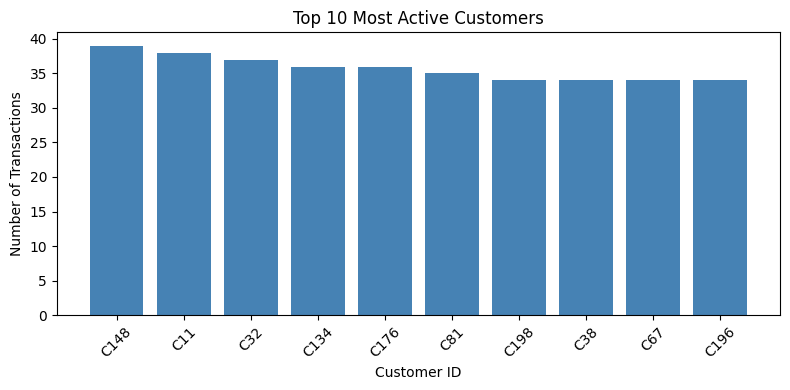

In [8]:
# CHART: Transactions of top 10 most active customers
patterns = spark.sql("""
SELECT customer_id, COUNT(*) AS num_transactions
FROM sales GROUP BY customer_id
ORDER BY num_transactions DESC LIMIT 10
""").toPandas()

plt.bar(patterns["customer_id"], patterns["num_transactions"], color="steelblue")
plt.title("Top 10 Most Active Customers")
plt.xlabel("Customer ID"); plt.ylabel("Number of Transactions")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

In [9]:
# (b) Top 10 selling products
print("--- Top 10 Selling Products ---")
spark.sql("""
SELECT product, SUM(quantity) AS total_qty
FROM sales
GROUP BY product
ORDER BY total_qty DESC
LIMIT 10
""").show()

--- Top 10 Selling Products ---
+----------+---------+
|   product|total_qty|
+----------+---------+
|    Mobile|     1325|
|     Shoes|     1317|
|      Sofa|     1304|
|      Book|     1301|
|    Laptop|     1274|
|      Rice|     1267|
|Headphones|     1253|
|       Pen|     1213|
|     Jeans|     1200|
|        TV|     1199|
+----------+---------+



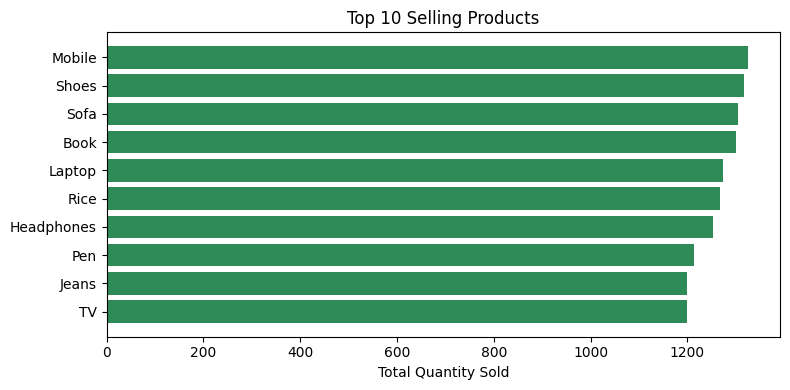

In [10]:
# CHART: Top 10 selling products
top_products = spark.sql("""
SELECT product, SUM(quantity) AS total_qty
FROM sales GROUP BY product
ORDER BY total_qty DESC LIMIT 10
""").toPandas()

plt.barh(top_products["product"], top_products["total_qty"], color="seagreen")
plt.title("Top 10 Selling Products")
plt.xlabel("Total Quantity Sold")
plt.gca().invert_yaxis()   # highest at top
plt.tight_layout(); plt.show()

In [11]:
# (c) Category-wise revenue
print("--- Category-wise Revenue ---")
spark.sql("""
SELECT category, ROUND(SUM(quantity*price),2) AS revenue
FROM sales
GROUP BY category
ORDER BY revenue DESC
""").show()

--- Category-wise Revenue ---
+-----------+----------+
|   category|   revenue|
+-----------+----------+
|Electronics|2605406.74|
|  Furniture| 524356.97|
|   Clothing|  148461.3|
|    Grocery|  21871.21|
| Stationery|   17982.9|
+-----------+----------+



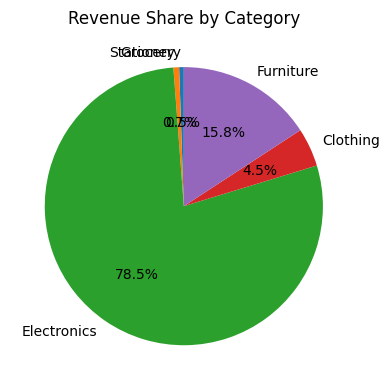

In [12]:
# CHART: Category-wise revenue share (pie chart)
cat_rev = spark.sql("""
SELECT category, SUM(quantity*price) AS revenue
FROM sales GROUP BY category
""").toPandas()

plt.pie(cat_rev["revenue"], labels=cat_rev["category"], autopct="%1.1f%%", startangle=90)
plt.title("Revenue Share by Category")
plt.tight_layout(); plt.show()

In [13]:
# (d) Top 5 customers by total purchase amount
print("--- Top 5 Customers ---")
spark.sql("""
SELECT customer_id, ROUND(SUM(quantity*price),2) AS total_purchase
FROM sales
GROUP BY customer_id
ORDER BY total_purchase DESC
LIMIT 5
""").show()

--- Top 5 Customers ---
+-----------+--------------+
|customer_id|total_purchase|
+-----------+--------------+
|        C28|      32976.48|
|       C166|      31119.57|
|        C17|      29688.26|
|       C198|      29546.31|
|        C22|      28480.45|
+-----------+--------------+



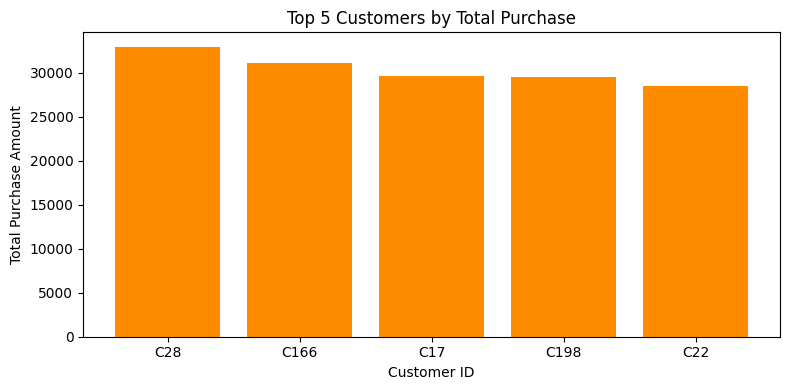

In [14]:
# CHART: Top 5 customers by total purchase amount
top_cust = spark.sql("""
SELECT customer_id, SUM(quantity*price) AS total_purchase
FROM sales GROUP BY customer_id
ORDER BY total_purchase DESC LIMIT 5
""").toPandas()

plt.bar(top_cust["customer_id"], top_cust["total_purchase"], color="darkorange")
plt.title("Top 5 Customers by Total Purchase")
plt.xlabel("Customer ID"); plt.ylabel("Total Purchase Amount")
plt.tight_layout(); plt.show()

In [15]:
# (e) Monthly sales trends
print("--- Monthly Sales Trend ---")
spark.sql("""
SELECT month(purchase_date) AS month,
       ROUND(SUM(quantity*price),2) AS sales
FROM sales
GROUP BY month(purchase_date)
ORDER BY month
""").show()

--- Monthly Sales Trend ---
+-----+---------+
|month|    sales|
+-----+---------+
|    1|303478.97|
|    2|252413.41|
|    3|257425.25|
|    4|241326.03|
|    5|254303.68|
|    6|268156.38|
|    7|310479.03|
|    8|293063.93|
|    9|265926.52|
|   10|293778.23|
|   11|310204.35|
|   12|267523.34|
+-----+---------+



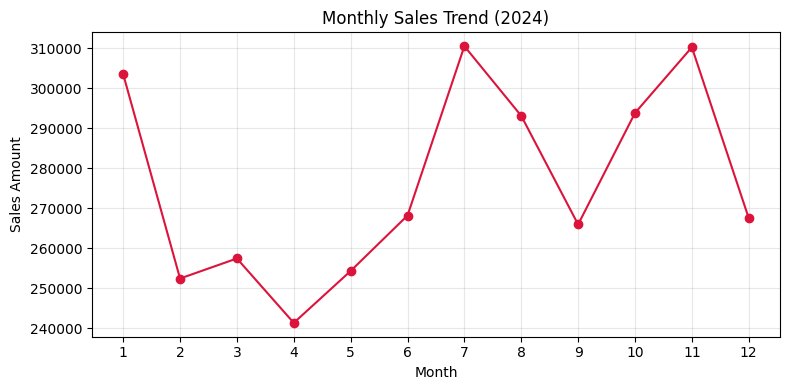

In [16]:
# CHART: Monthly sales trend (line chart)
monthly = spark.sql("""
SELECT month(purchase_date) AS month, SUM(quantity*price) AS sales
FROM sales GROUP BY month(purchase_date) ORDER BY month
""").toPandas()

plt.plot(monthly["month"], monthly["sales"], marker="o", color="crimson")
plt.title("Monthly Sales Trend (2024)")
plt.xlabel("Month"); plt.ylabel("Sales Amount")
plt.xticks(range(1, 13)); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Additional EDA Charts
Distribution of transaction amounts and quantity — useful to understand data spread before ML.

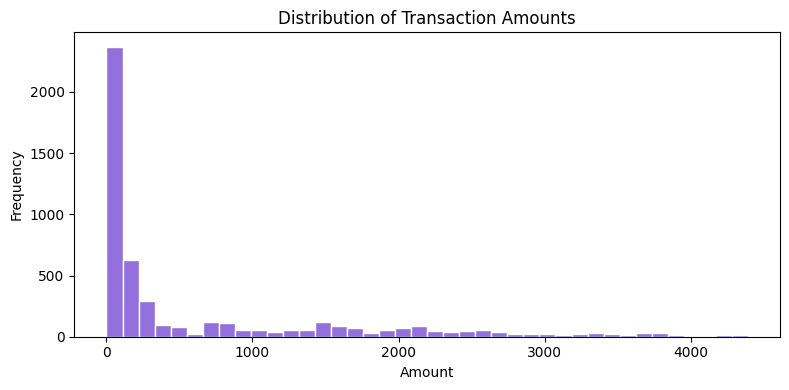

In [17]:
# CHART: Distribution of transaction amounts (histogram)
amounts = df.selectExpr("quantity*price as amount").toPandas()

plt.hist(amounts["amount"], bins=40, color="mediumpurple", edgecolor="white")
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Amount"); plt.ylabel("Frequency")
plt.tight_layout(); plt.show()

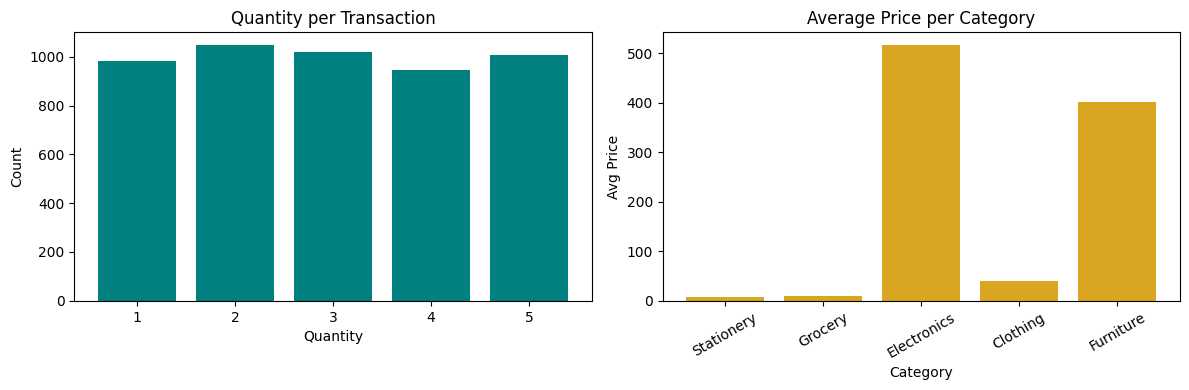

In [18]:
# CHART: Quantity distribution + average price per category (side by side)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Quantity counts
qty = df.groupBy("quantity").count().orderBy("quantity").toPandas()
ax[0].bar(qty["quantity"], qty["count"], color="teal")
ax[0].set_title("Quantity per Transaction")
ax[0].set_xlabel("Quantity"); ax[0].set_ylabel("Count")

# Average price per category
avg_price = df.groupBy("category").agg(avg("price").alias("avg_price")).toPandas()
ax[1].bar(avg_price["category"], avg_price["avg_price"], color="goldenrod")
ax[1].set_title("Average Price per Category")
ax[1].set_xlabel("Category"); ax[1].set_ylabel("Avg Price")
ax[1].tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()

## Q6. ETL Pipeline (3 Marks)
- **Extract** → read raw CSV
- **Transform** → drop nulls, remove invalid rows, add `amount` column
- **Load** → save cleaned data as CSV and Parquet

In [19]:
# EXTRACT
raw = spark.read.csv("synthetic_transactions.csv", header=True, inferSchema=True)
print("Extracted rows:", raw.count())

# TRANSFORM
clean = raw.dropna()                                   # remove nulls
clean = clean.filter((col("quantity") > 0) & (col("price") > 0))   # remove invalid rows
clean = clean.withColumn("amount", col("quantity") * col("price")) # new column
print("Rows after cleaning:", clean.count())
clean.show(5)

# LOAD
clean.write.mode("overwrite").csv("processed_sales", header=True)
clean.write.mode("overwrite").parquet("processed_sales_parquet")
print("ETL complete: data saved to processed_sales/ and processed_sales_parquet/")

Extracted rows: 5000
Rows after cleaning: 5000
+--------------+-----------+-------+-----------+--------+------+-------------+-------+
|transaction_id|customer_id|product|   category|quantity| price|purchase_date| amount|
+--------------+-----------+-------+-----------+--------+------+-------------+-------+
|             1|        C63|    Pen| Stationery|       1|  1.81|   2024-05-20|   1.81|
|             2|       C190|     TV|Electronics|       2|733.11|   2024-12-12|1466.22|
|             3|         C8|    Oil|    Grocery|       1|  8.14|   2024-01-17|   8.14|
|             4|         C7| Mobile|Electronics|       2|473.27|   2024-11-04| 946.54|
|             5|       C140|    Oil|    Grocery|       2|  8.35|   2024-12-25|   16.7|
+--------------+-----------+-------+-----------+--------+------+-------------+-------+
only showing top 5 rows
ETL complete: data saved to processed_sales/ and processed_sales_parquet/


## Q7. Machine Learning (2 Marks)
Logistic Regression to predict a **high-value purchase** (amount > 500), evaluated with Accuracy and AUC.

In [20]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# Label: 1 if amount > 500 else 0
ml_df = clean.withColumn("label", (col("amount") > 500).cast("int"))

# Features
assembler = VectorAssembler(inputCols=["quantity", "price"], outputCol="features")
data = assembler.transform(ml_df).select("features", "label")

# Train / Test split
train, test = data.randomSplit([0.8, 0.2], seed=42)

# Train model
lr = LogisticRegression()
model = lr.fit(train)

# Predict
pred = model.transform(test)
pred.select("features", "label", "prediction").show(10)

# Evaluate
acc = MulticlassClassificationEvaluator(metricName="accuracy").evaluate(pred)
auc = BinaryClassificationEvaluator().evaluate(pred)
print("Accuracy:", round(acc, 4))
print("AUC:", round(auc, 4))

+----------+-----+----------+
|  features|label|prediction|
+----------+-----+----------+
|[1.0,1.81]|    0|       0.0|
|[1.0,1.83]|    0|       0.0|
|[1.0,1.84]|    0|       0.0|
|[1.0,1.86]|    0|       0.0|
| [1.0,1.9]|    0|       0.0|
|[1.0,1.91]|    0|       0.0|
|[1.0,1.93]|    0|       0.0|
|[1.0,1.96]|    0|       0.0|
|[1.0,1.98]|    0|       0.0|
|[1.0,1.98]|    0|       0.0|
+----------+-----+----------+
only showing top 10 rows
Accuracy: 0.9916
AUC: 0.9999


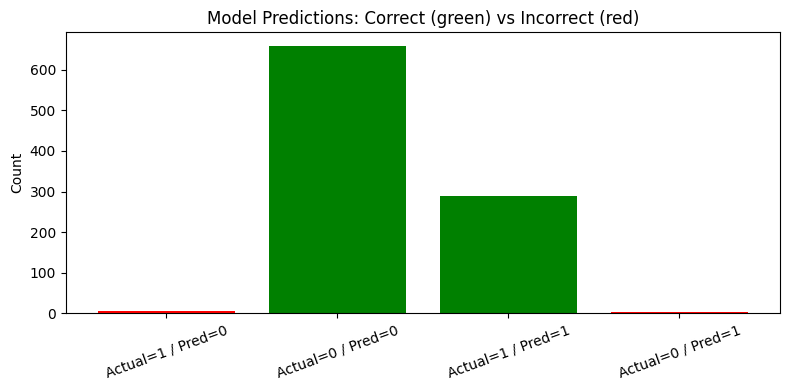

In [21]:
# CHART: Prediction results - actual vs predicted counts
result = pred.groupBy("label", "prediction").count().toPandas()
result["group"] = "Actual=" + result["label"].astype(str) + " / Pred=" + result["prediction"].astype(int).astype(str)

plt.bar(result["group"], result["count"], color=["green" if l == p else "red" for l, p in zip(result["label"], result["prediction"])])
plt.title("Model Predictions: Correct (green) vs Incorrect (red)")
plt.ylabel("Count"); plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

In [22]:
# Stop Spark when done
spark.stop()
print("Spark session stopped.")

Spark session stopped.
